In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [10]:
df=df.dropna(subset=['type','country','rating','duration','release_year'])
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [11]:
type_counts=df['type'].value_counts()
print(type_counts)

type
Movie      5687
TV Show    2283
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(6,4), dpi=100)

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

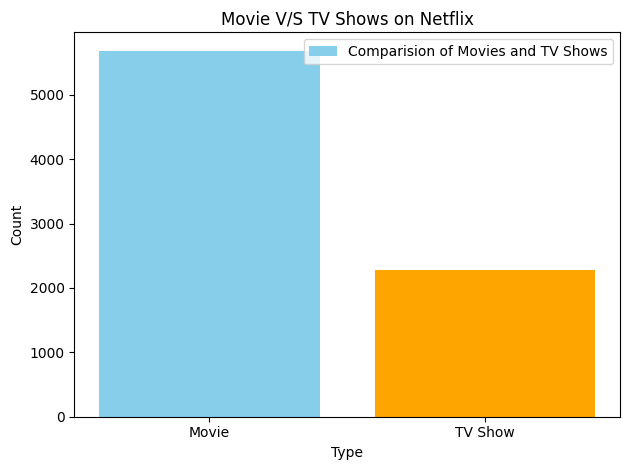

In [13]:
plt.bar(type_counts.index,type_counts.values, color=['skyblue','orange'], label='Comparision of Movies and TV Shows')
plt.legend()
plt.title('Movie V/S TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png', dpi=300)
plt.show()

In [14]:
rating_counts = df['rating'].value_counts()
print(rating_counts)

rating
TV-MA       2931
TV-14       1930
R            788
TV-PG        773
PG-13        482
PG           281
TV-Y7        236
TV-Y         227
TV-G         190
NR            80
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64


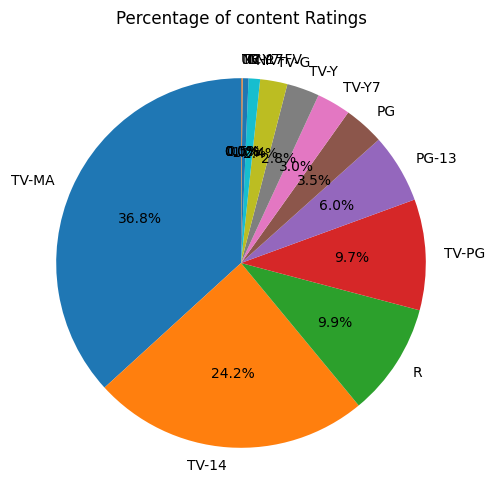

In [23]:
plt.figure(figsize=(8,6))
plt.pie(rating_counts,labels=rating_counts.index,autopct='%1.1f%%', startangle=90)
plt.title('Percentage of content Ratings')
plt.savefig('percentage_ratings.png', dpi=300)

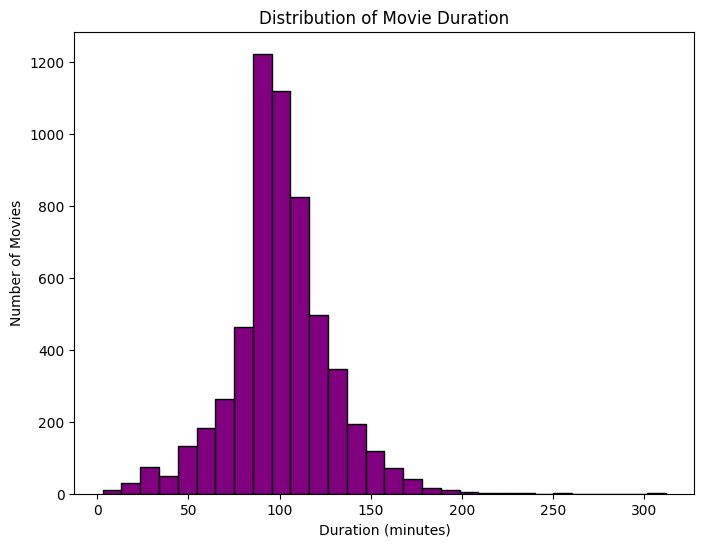

In [16]:
movie_df=df[df['type']=='Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min','').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor='black')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.savefig('movie_distribution.png', dpi=300)
plt.show()

release_year
1942       2
1943       3
1944       3
1945       4
1946       2
        ... 
2017     965
2018    1038
2019     913
2020     852
2021     383
Name: count, Length: 73, dtype: int64


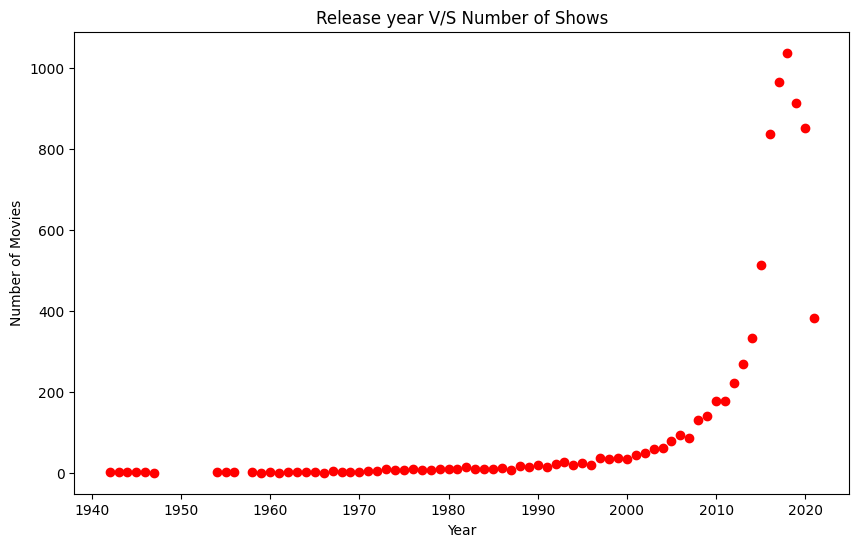

In [17]:
release_counts=df['release_year'].value_counts().sort_index()
print(release_counts)
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values, color='red')
plt.title('Release year V/S Number of Shows')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.savefig('release_year.png', dpi=300)
plt.show()


country
United States     2815
India              972
United Kingdom     419
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


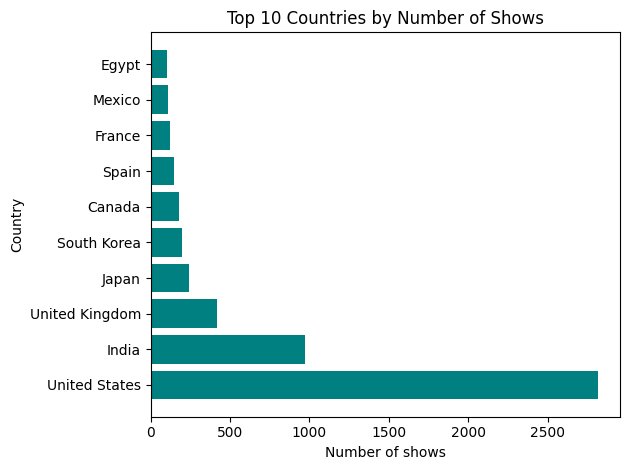

In [18]:
country_counts = df['country'].value_counts().head(10)
print(country_counts)
plt.barh(country_counts.index,country_counts.values, color='teal')
plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top_10_countries.png', dpi=300)
plt.show()

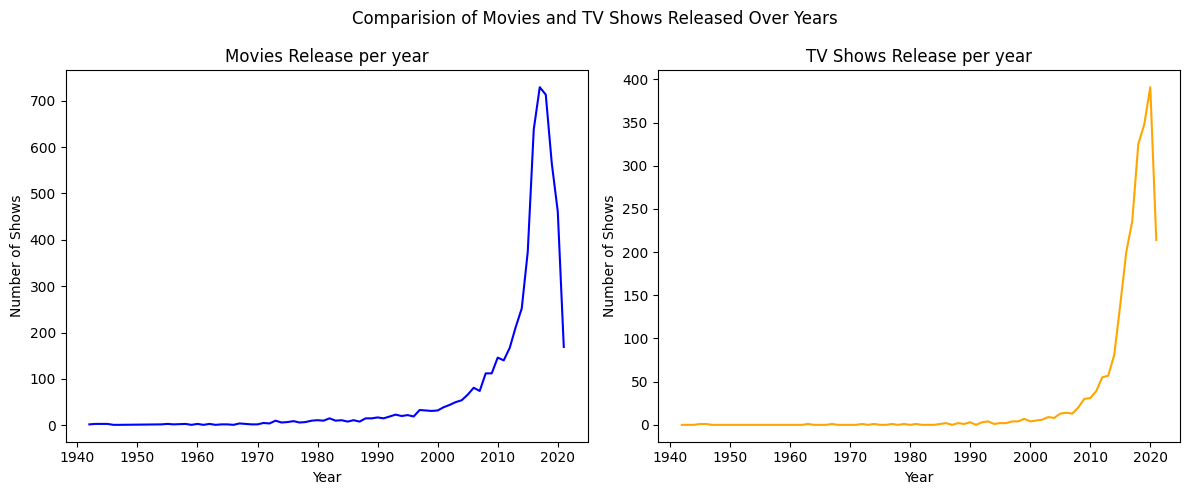

In [19]:
content_by_year=df.groupby(['release_year','type']).size().unstack().fillna(0)
fig,ax=plt.subplots(1,2, figsize=(12,5))

ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title('Movies Release per year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Shows')


ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[1].set_title('TV Shows Release per year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of Shows')

fig.suptitle('Comparision of Movies and TV Shows Released Over Years')
plt.tight_layout()
plt.savefig('movies_tv_shows_comparision.png')
plt.show()